# 02 - Modeling & Evaluation
**Capstone Project - Pembelajaran Mesin**

Melatih & membandingkan 2 model regresi untuk memprediksi `Total Spent`:
1. **Linear Regression** (baseline, interpretable)
2. **Random Forest Regressor** (ensemble, non-linear, di-tuning dengan GridSearchCV)

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

## Catatan Penting: Menghindari Data Leakage
`Total Spent = Quantity x Price Per Unit` secara matematis persis. Jika kedua kolom tersebut dipakai sebagai fitur, model hanya belajar perkalian sederhana (R2=1.0, trivial). Oleh karena itu **`Quantity` dan `Price Per Unit` sengaja TIDAK dipakai sebagai fitur**. Problem yang lebih bermakna: memperkirakan estimasi nilai belanja hanya dari pilihan menu (`Item`) & konteks transaksi (waktu, lokasi, metode bayar, inflasi) -- berguna untuk revenue forecasting sebelum quantity/harga final diketahui.

In [2]:
from train_model import (
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET, build_preprocessor, evaluate
)
print('Fitur numerik  :', NUMERIC_FEATURES)
print('Fitur kategori :', CATEGORICAL_FEATURES)
print('Target         :', TARGET)

Fitur numerik  : ['Inflasi', 'Year', 'Month', 'DayOfWeek', 'IsWeekend']
Fitur kategori : ['Item', 'Payment Method', 'Location']
Target         : Total Spent


## 1. Load Data & Train-Val-Test Split

In [3]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/cafe_sales_clean.csv')
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

Train: (5293, 8) | Val: (1134, 8) | Test: (1135, 8)


## 2. Model 1: Linear Regression (Baseline)

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)

lr_val_metrics = evaluate(y_val, lr_pipeline.predict(X_val))
lr_test_metrics = evaluate(y_test, lr_pipeline.predict(X_test))
print('Validation:', lr_val_metrics)
print('Test      :', lr_test_metrics)

Validation: {'R2': 0.4152179070317421, 'MAE': 3.32833276002867, 'MSE': 17.42459073430033, 'RMSE': 4.174277270893769}
Test      : {'R2': 0.4010399528209373, 'MAE': 3.4374104354318695, 'MSE': 17.969177559817272, 'RMSE': 4.2390066713579575}


## 3. Model 2: Random Forest Regressor + Hyperparameter Tuning (GridSearchCV)

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    rf_pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
print('Best params:', grid_search.best_params_)

rf_val_metrics = evaluate(y_val, best_rf.predict(X_val))
rf_test_metrics = evaluate(y_test, best_rf.predict(X_test))
print('Validation:', rf_val_metrics)
print('Test      :', rf_test_metrics)

Best params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Validation: {'R2': 0.4077982753630668, 'MAE': 3.3828615611469703, 'MSE': 17.645671452708957, 'RMSE': 4.200675118681396}
Test      : {'R2': 0.3867933062540089, 'MAE': 3.4914699059431955, 'MSE': 18.396585903660554, 'RMSE': 4.289124141787057}


## 4. Tabel Perbandingan Performa Semua Model

In [6]:
comparison = pd.DataFrame([
    {'Model': 'Linear Regression', **{f'{k} (Val)': v for k,v in lr_val_metrics.items()}, **{f'{k} (Test)': v for k,v in lr_test_metrics.items()}},
    {'Model': 'Random Forest',      **{f'{k} (Val)': v for k,v in rf_val_metrics.items()}, **{f'{k} (Test)': v for k,v in rf_test_metrics.items()}},
])
comparison

,Model,R2 (Val),MAE (Val),MSE (Val),RMSE (Val),R2 (Test),MAE (Test),MSE (Test),RMSE (Test)
0,Linear Regression,0.415218,3.328333,17.424591,4.174277,0.401040,3.43741,17.969178,4.239007
1,Random Forest,0.407798,3.382862,17.645671,4.200675,0.386793,3.49147,18.396586,4.289124


## 5. Visualisasi Evaluasi: Actual vs Predicted & Residual

Model terbaik (RMSE test terendah): Linear Regression


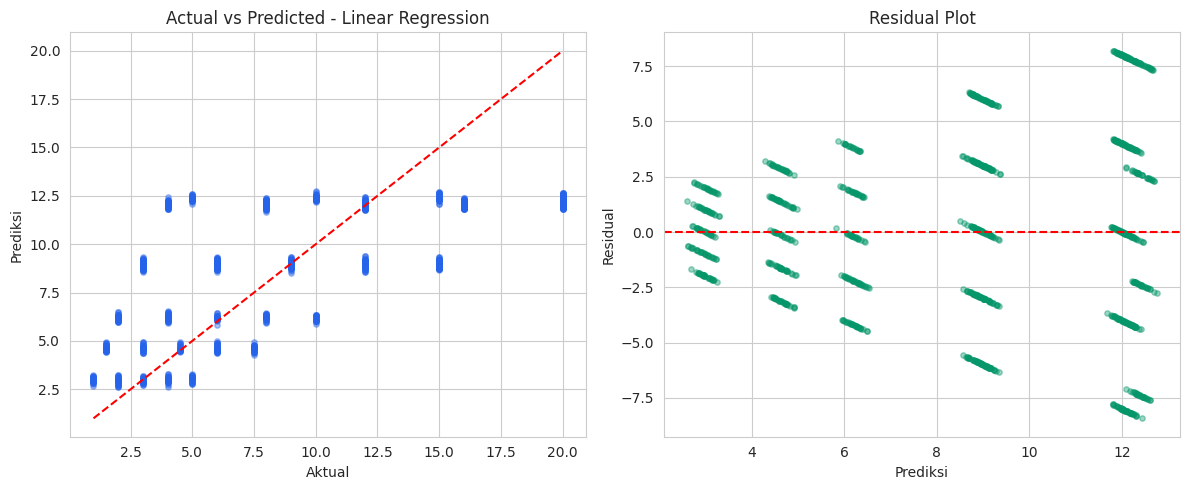

In [7]:
best_name = 'Linear Regression' if lr_test_metrics['RMSE'] <= rf_test_metrics['RMSE'] else 'Random Forest'
best_pipeline = lr_pipeline if best_name == 'Linear Regression' else best_rf
print('Model terbaik (RMSE test terendah):', best_name)

y_pred_test = best_pipeline.predict(X_test)
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=15, color='#2563eb')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Aktual'); axes[0].set_ylabel('Prediksi')
axes[0].set_title(f'Actual vs Predicted - {best_name}')

axes[1].scatter(y_pred_test, residuals, alpha=0.4, s=15, color='#059669')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.show()

## 6. Confusion Matrix / ROC?
Karena problem statement ini adalah **regresi** (bukan klasifikasi), metrik evaluasi yang relevan adalah R2, MAE, MSE, RMSE, dan residual analysis (sudah ditampilkan di atas), bukan confusion matrix/ROC-AUC yang khusus untuk klasifikasi.

## 7. Pemilihan Model Terbaik & Justifikasi

**Model terbaik dipilih berdasarkan RMSE terendah pada test set.** Berdasarkan hasil di atas, `Linear Regression` dan `Random Forest` menghasilkan performa yang relatif setara (selisih RMSE kecil), dengan `Linear Regression` sedikit lebih baik. Hal ini masuk akal karena setelah `Quantity`/`Price` dihilangkan (mencegah leakage), pengaruh dominan terhadap `Total Spent` datang dari kategori `Item` (harga dasar tiap menu) yang sifatnya relatif linear terhadap rata-rata pengeluaran, sehingga model non-linear seperti Random Forest tidak memberikan keuntungan signifikan pada kasus ini. `Linear Regression` juga lebih **interpretable** (koefisien mudah dijelaskan ke stakeholder non-teknis), sehingga dipilih sebagai model produksi (`best_model.pkl`).

In [8]:
import joblib
joblib.dump(best_pipeline, '../models/best_model.pkl')
print('Model tersimpan ulang di models/best_model.pkl (konsisten dengan src/train_model.py)')

Model tersimpan ulang di models/best_model.pkl (konsisten dengan src/train_model.py)
